In [1]:
import os 
api_key=os.getenv("SER_API")

if api_key is None:
    print("no API")
else:
    print("i find my key")

i find my key


## OpenRouter Connection

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=api_key,
    model="openai/gpt-4o-mini",
    temperature=0
)

response = llm.invoke("Hello")

print(response.content)

/home/mona/Documents/LLM_project/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Hello! How can I assist you today?


## translate input users query  to Compilar arxiv query

In [3]:
#from langchain.prompts import PromptTemplate

from langchain_core.prompts import PromptTemplate

template = """
You are an arXiv query optimization system.

Your task is to convert user requests into concise and effective arXiv search queries.

Rules:
1. Use only concise technical keywords.
2. Avoid unnecessary phrases like:
   "research papers", "studies about", "articles about".
3. Expand abbreviations into standard technical terms when beneficial for retrieval.
4. Use Boolean operators (AND, OR) only if necessary.
5. Focus on retrieval quality for arXiv.
6. Return ONLY the final query.
7. Keep the query short and search-engine friendly.

User Request:
{user_input}

Optimized arXiv Query:"""

query_prompt = PromptTemplate.from_template(template)

# Function to translate query
def generate_arxiv_query(user_input):
    chain = query_prompt | llm
    response = chain.invoke({"user_input": user_input})
    return response.content.strip()

Prefix, Description, Example

`ti:`, Title, Searches for the word only in the title of the research paper.

`abs:`, Abstract, Searches the abstract of the research (the part that describes the patent or innovation).

`au:`, Author, Searches for a specific author.

`cat:`, Subject Category, Searches within a specific category (e.g., cs.AI for artificial intelligence).

`all:`, All fields, Searches in all fields (default).


In [ ]:
querys = generate_arxiv_query("last papers for Data scince and ML")
test_query= generate_arxiv_query("Jeffrey Hinton's Deep Learning Research")
print(querys)
print(test_query)

data science OR machine learning
Hinton AND "deep learning"


## LLM Query Optimizer → arXiv Search (old)

## Structured Schema Design

In [ ]:
import arxiv
import time
def to_schema(result):
    return {  #Clean Retrieval Output (Good Practice)
            "paper_id": result.entry_id,
            "title": result.title,
            "year": result.published.year,
            "published": str(result.published),
            "authors": [author.name for author in result.authors],
            "summary": result.summary.replace("\n", " ").strip(),
            "url": result.pdf_url,
        }
def search_arxiv(query):

    client = arxiv.Client(page_size=100,
    delay_seconds=1.0,
    num_retries=5) ###

    search = arxiv.Search(
        query=query,
        max_results=5,
        sort_by=arxiv.SortCriterion.Relevance
    )

    

    results = []
    for result in client.results(search):
        results.append(to_schema(result))
        time.sleep(1)
    return results


In [ ]:
#only test
#query = generate_arxiv_query(test_query)
#results = search_arxiv(query)
#print(query)

Hinton AND deep learning


In [ ]:
#only test
#q2 = "robotics AND AI"

#results = search_arxiv(q2)

#print(len(results))

5


In [ ]:
#only test 
#for r in results:
#    print("=" * 40)
#    print(r["title"])

Embodied AI with Foundation Models for Mobile Service Robots: A Systematic Review
Towards Transparent Ethical AI: A Roadmap for Trustworthy Robotic Systems
Adaptive Prior Selection for Repertoire-based Online Adaptation in Robotics
Graph Neural Networks for Learning Robot Team Coordination
Gemini Robotics: Bringing AI into the Physical World


In [ ]:
# only test
#test_query2 = "stil papers about UAS systems"

#query3 = generate_arxiv_query(test_query2)

#print("QUERY:", query3)

#results = search_arxiv(query3) ### this

#print("RESULT COUNT:", len(results))

#for r in results:
#    print(r["title"])



QUERY: UAS systems
RESULT COUNT: 5
Counter-Unmanned Aircraft System(s) (C-UAS): State of the Art, Challenges and Future Trends
Symmetries and periodic orbits in simple hybrid Routhian systems
Safe Human-UAS Collaboration Abstraction
A Review of the Operational Use of UAS in Public Safety Emergency Incidents
Adaptive Backstepping Control for Fractional-Order Nonlinear Systems with External Disturbance and Uncertain Parameters Using Smooth Control


In [ ]:
import json
# FOR TEST
#qa = generate_arxiv_query("deep learning with robotecs")
#results = search_arxiv(qa)

#with open("results.json", "w") as f:
#    json.dump(results, f, indent=4)

def run_pipeline(user_query):
    # FOR REAL
    arxiv_query = generate_arxiv_query(user_query)

    results = search_arxiv(arxiv_query)

    with open("results.json", "w") as f:
        json.dump(results, f, indent=4)

    return results

### uploud file `resulls.json` incude the result for my quiry>

## Embeddings

In [24]:
########## only test code 
from sentence_transformers import SentenceTransformer


In [25]:
model = SentenceTransformer(
    "BAAI/bge-large-en-v1.5",
    device="cpu"
)

paper_embeddings = []


for paper in results:

    text = f"{paper['title']} {paper['summary']}"

    embedding = model.encode(text) 

    paper["embedding"] = embedding
    paper_embeddings.append(paper)

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 9483.89it/s]


In [8]:
#print(type(embedding)) 
#print(embedding.shape)

<class 'numpy.ndarray'>
(1024,)


In [9]:
#print(embedding)

[ 0.00783807  0.02499729 -0.0238185  ... -0.01896117  0.02344734
  0.02468724]


In [10]:
#model.encode(text) 

array([ 0.00783807,  0.02499729, -0.0238185 , ..., -0.01896117,
        0.02344734,  0.02468724], shape=(1024,), dtype=float32)

In [ ]:
# this only for test but if i usre cosine similarity it's nothing 
#similarities = model.similarity(embedding, embedding)
#print(similarities)

tensor([[1.0000]])


#### Make sure the data is available

In [26]:
print("TOTAL:", len(paper_embeddings))

print("\nFIRST PAPER:")
print(paper_embeddings[0]["title"])

print("\nVECTOR SIZE:")
print(len(paper_embeddings[0]["embedding"]))

TOTAL: 5

FIRST PAPER:
Optimal Deep Learning for Robot Touch

VECTOR SIZE:
1024


## cosine_similarity

In [27]:
from sklearn.metrics.pairwise import cosine_similarity 
import pandas as pd

In [28]:
embeddings = [
    paper["embedding"]
    for paper in paper_embeddings
]

similarity_matrix = cosine_similarity(
    embeddings
)

titles = [
    paper["title"]
    for paper in paper_embeddings
]

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=titles,
    columns=titles
)

print(similarity_df)

                                                    Optimal Deep Learning for Robot Touch  \
Optimal Deep Learning for Robot Touch                                            1.000000   
Model Predictive Actor-Critic: Accelerating Rob...                               0.782263   
A Comparative Study on Machine Learning Algorit...                               0.741258   
Learning Optimal Topology for Ad-hoc Robot Netw...                               0.746260   
Scaling data-driven robotics with reward sketch...                               0.774468   

                                                    Model Predictive Actor-Critic: Accelerating Robot Skill Acquisition with Deep Reinforcement Learning  \
Optimal Deep Learning for Robot Touch                                                        0.782263                                                      
Model Predictive Actor-Critic: Accelerating Rob...                                           1.000000                            

## Visualization by heatmap

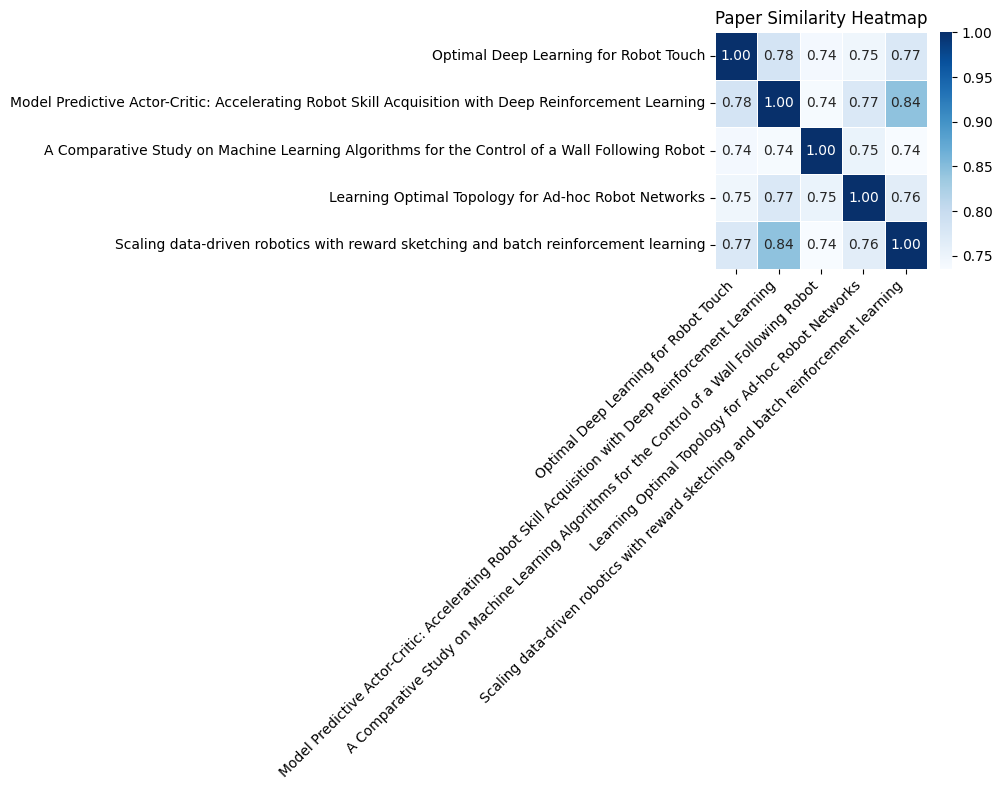

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.heatmap(
    similarity_df,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Paper Similarity Heatmap")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

In [30]:
# not use this code only semantix matrix 
# not nead cosign semantix 
#embedding1 = paper_embeddings[0]["embedding"]
#embedding2 = paper_embeddings[1]["embedding"]

#similarity = cosine_similarity(
#    [embedding1],
#    [embedding2])

#print(similarity)

[[0.7822626]]


## similarity Matrix

## Choroma DB 

3 things to do hear:
- made Database
- make collection
- load papers and embeddings 

In [32]:
import chromadb 
# client = chromadb.Client()
client = chromadb.PersistentClient(path="./chroma_db")

collection = client.get_or_create_collection(  #delet cteat collection
    name="research_papers"
)

In [33]:
try:
    client.delete_collection("research_papers")
except:
    pass

collection = client.get_or_create_collection(
    name="research_papers"
)

for idx, paper in enumerate(paper_embeddings):

    collection.add(

        ids=[str(idx)],

        embeddings=[
            paper["embedding"].tolist()
        ],

        metadatas=[
            {
                "title": paper["title"],
                "year": paper["year"]
            }
        ],

        documents=[paper["title"]]
    )

print("chroma DB")

chroma DB 


In [20]:
print(collection.count())

5


In [34]:
#results

[{'paper_id': 'http://arxiv.org/abs/2003.01916v2',
  'title': 'Optimal Deep Learning for Robot Touch',
  'year': 2020,
  'published': '2020-03-04 06:55:19+00:00',
  'authors': ['Nathan F. Lepora', 'John Lloyd'],
  'summary': 'This article illustrates the application of deep learning to robot touch by considering a basic yet fundamental capability: estimating the relative pose of part of an object in contact with a tactile sensor. We begin by surveying deep learning applied to tactile robotics, focussing on optical tactile sensors, which help bridge from deep learning for vision to touch. We then show how deep learning can be used to train accurate pose models of 3D surfaces and edges that are insensitive to nuisance variables such as motion-dependent shear. This involves including representative motions as unlabelled perturbations of the training data and using Bayesian optimization of the network and training hyperparameters to find the most accurate models. Accurate estimation of pos

### Structuring Layer

In [61]:
import re
def safe_parse_llm_output(text):
   
    match = re.search(r"\{.*\}", text, re.DOTALL)

    if match:
        try:
            return json.loads(match.group())
        except:
            return None
    return None

In [ ]:
def structure_paper(paper):
    prompt = f"""
Extract structured research information:

Title: {paper['title']}
Summary: {paper['summary']}


Return JSON with:
- problem
- method
- contribution
- limitations
- keywords

Return ONLY valid JSON. No explanation. No markdown.
"""

    response = llm.invoke(prompt).content
    #return json.loads(response)
    return safe_parse_llm_output(response)

In [44]:
# using
#structured_query = "deep learning for object detection in robotics"
# arxiv
#qs = generate_arxiv_query(structured_query)
#print("ARXIV QUERY:", qs)


# structuring layer 
#papers = search_arxiv(qs)

structured_papers = []

for p in results: #it was 'papers' in test
    structured = structure_paper(p)
    structured_papers.append(structured)

#print(structured_papers[0])
with open("structured_papers.json", "w") as f:
    json.dump(structured_papers, f, indent=4)

for i, paper in enumerate(structured_papers):
    print(f"\n===== PAPER {i+1} =====")
    print(json.dumps(paper, indent=4))
#print(json.dumps(structured_papers[0], indent=4))

ARXIV QUERY: deep learning AND object detection AND robotics

===== PAPER 1 =====
{
    "problem": "Oriented object detection in remote sensing images, including challenges like feature misalignment, spatial misalignment, oriented bounding box (OBB) regression problems, and common issues in remote sensing.",
    "method": "A comprehensive survey of recent advances in oriented object detection methods, categorizing them into detection frameworks, OBB regression techniques, feature representation approaches, and solutions to common issues.",
    "contribution": "Provides an in-depth discussion of methods addressing challenges in oriented object detection, covers publicly available datasets and evaluation protocols, and offers a comprehensive comparison and analysis of state-of-the-art methods.",
    "limitations": "The survey may not cover all emerging methods or datasets as the field is rapidly evolving.",
    "keywords": [
        "oriented object detection",
        "remote sensing",


## Graph RAG

In [46]:
import networkx as nx

G = nx.Graph()


for i, title in enumerate(titles):
    G.add_node(i, title=title)

In [47]:
threshold = 0.75 # or 80

In [48]:
for i in range(len(similarity_matrix)):
    for j in range(i + 1, len(similarity_matrix)):
        score = similarity_matrix[i][j]

        if score >= threshold:
            G.add_edge(i, j, weight=float(score))

In [49]:
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 5
Edges: 6


In [50]:
for u, v, data in G.edges(data=True):
    print(
        titles[u],
        "<->",
        titles[v],
        "=>",
        round(data["weight"], 3)
    )

Optimal Deep Learning for Robot Touch <-> Model Predictive Actor-Critic: Accelerating Robot Skill Acquisition with Deep Reinforcement Learning => 0.782
Optimal Deep Learning for Robot Touch <-> Scaling data-driven robotics with reward sketching and batch reinforcement learning => 0.774
Model Predictive Actor-Critic: Accelerating Robot Skill Acquisition with Deep Reinforcement Learning <-> Learning Optimal Topology for Ad-hoc Robot Networks => 0.775
Model Predictive Actor-Critic: Accelerating Robot Skill Acquisition with Deep Reinforcement Learning <-> Scaling data-driven robotics with reward sketching and batch reinforcement learning => 0.845
A Comparative Study on Machine Learning Algorithms for the Control of a Wall Following Robot <-> Learning Optimal Topology for Ad-hoc Robot Networks => 0.753
Learning Optimal Topology for Ad-hoc Robot Networks <-> Scaling data-driven robotics with reward sketching and batch reinforcement learning => 0.764


## Community Detection for my rag

In [51]:
from networkx.algorithms.community import greedy_modularity_communities

clusters = list(greedy_modularity_communities(G))

for i, cluster in enumerate(clusters):
    print(f"\n===== CLUSTER {i+1} =====")
    
    for node in cluster:
        print(titles[node])


===== CLUSTER 1 =====
Optimal Deep Learning for Robot Touch
Model Predictive Actor-Critic: Accelerating Robot Skill Acquisition with Deep Reinforcement Learning
Scaling data-driven robotics with reward sketching and batch reinforcement learning

===== CLUSTER 2 =====
A Comparative Study on Machine Learning Algorithms for the Control of a Wall Following Robot
Learning Optimal Topology for Ad-hoc Robot Networks


## Survey-ready structured output

In [ ]:
def build_cluster_insight(cluster, titles):
    
    papers_text = "\n".join([titles[i] for i in cluster])

    prompt = f"""
You are a research analyst specialized in synthesizing academic literature.

Given a group of related research papers, analyze them and produce a structured research insight.

Papers:
{papers_text}

IMPORTANT RULES:
- Return ONLY valid JSON.
- Do NOT include explanations.
- Do NOT include markdown or code fences.
- Do NOT include any text before or after JSON.
- Ensure all keys exist even if empty (use "" or []).

Return JSON with this exact schema:
{{
  "theme_title": "",
  "summary": "",
  "key_concepts": [],
  "common_methods": "",
  "research_gaps": "",
  "potential_directions": ""
}}
"""
    
    response = llm.invoke(prompt).content
    #return response
    return safe_parse_llm_output(response)

In [59]:
cluster_insights = []

for cluster in clusters:
    insight = build_cluster_insight(cluster, titles)
    cluster_insights.append(insight)

## Survey Cards

In [ ]:
survey_data = []

for cluster, parsed in zip(clusters, cluster_insights):

    if not parsed:
        continue

    #papers_in_cluster = [titles[i] for i in cluster]

    survey_data.append({
        "theme_title": parsed.get("theme_title", ""),
        "summary": parsed.get("summary", ""),
        "key_concepts": parsed.get("key_concepts", []),
        "common_methods": parsed.get("common_methods", ""),
        "research_gaps": parsed.get("research_gaps", ""),
        "potential_directions": parsed.get("potential_directions", ""),
        #"papers": papers_in_cluster
    })

In [ ]:
with open("survey_data.json", "w") as f:
    json.dump(survey_data, f, indent=4)